In [33]:
import tensorflow as tf
from tensorflow.keras.layers import Lambda,Layer
import matplotlib.pyplot as plt 
from keras.models import save_model,load_model

In [6]:
IMAGE_SIZE = 256
BATCH_SIZE = 100
CHANNELS=3
EPOCHS=50

In [7]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "DataSet",
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 10000 files belonging to 10 classes.


In [8]:
class_name = dataset.class_names
class_name

['Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [10]:
len(dataset)

100

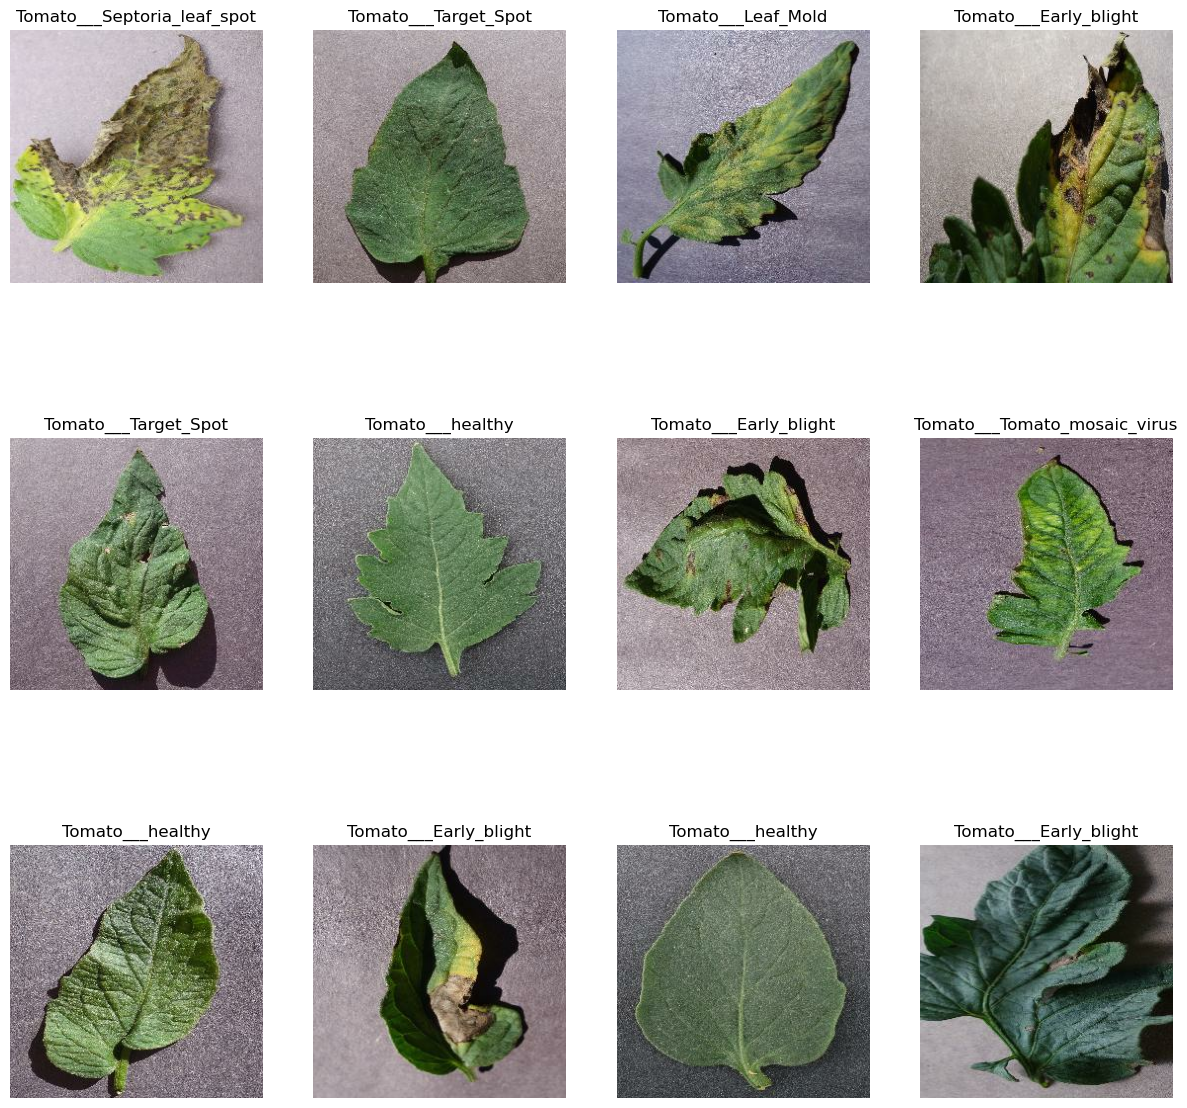

In [11]:
plt.figure(figsize=(15,15))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_name[label_batch[i]])
        plt.axis("off")


In [12]:
len(dataset)

100

In [13]:
train_size =0.8
len(dataset)*train_size

80.0

In [14]:
train_ds=dataset.take(250)
len(train_ds)

100

In [15]:
test_ds = dataset.skip(250)
len(test_ds)

0

In [16]:
val_size = 0.1
len(dataset)*val_size

10.0

In [17]:
val_ds = test_ds.skip(31)
len(val_ds)

0

In [18]:
test_ds = test_ds.skip(32)
len(test_ds)

0

In [19]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [20]:
train_ds,val_ds,test_ds = get_dataset_partitions_tf(dataset)

In [21]:
len(train_ds)

80

In [22]:
len(val_ds)

10

In [23]:
len(test_ds)

10

In [24]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [25]:
resize_and_rescale = tf.keras.Sequential([
  tf.keras.layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  tf.keras.layers.experimental.preprocessing.Rescaling(1.0/255),
])

In [26]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.experimental.preprocessing.RandomRotation(0.2),
])

In [27]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.experimental.preprocessing.RandomRotation(0.2),
])

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [28]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE,CHANNELS)
n_classes = 10

model = tf.keras.models.Sequential([
    resize_and_rescale,
    tf.keras.layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

from keras.preprocessing.image import ImageDataGenerator

aug = ImageDataGenerator(
    rotation_range=25, width_shift_range=0.1,
    height_shift_range=0.1, shear_range=0.2, 
    zoom_range=0.2,horizontal_flip=True, 
    fill_mode="nearest")

In [29]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (100, 256, 256, 3)        0         
                                                                 
 conv2d (Conv2D)             (100, 254, 254, 32)       896       
                                                                 
 max_pooling2d (MaxPooling2D  (100, 127, 127, 32)      0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (100, 125, 125, 64)       18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (100, 62, 62, 64)        0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (100, 60, 60, 64)        

In [25]:
history = model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
model.fit(train_ds,validation_data=val_ds,batch_size=BATCH_SIZE, epochs=50)

Epoch 1/50
80/80 [==============================] - 577s 7s/step - loss: 1.9996 - accuracy: 0.2399 - val_loss: 1.5979 - val_accuracy: 0.4310
Epoch 2/50
80/80 [==============================] - 381s 5s/step - loss: 1.2963 - accuracy: 0.5509 - val_loss: 0.9639 - val_accuracy: 0.6890
Epoch 3/50
80/80 [==============================] - 380s 5s/step - loss: 0.8847 - accuracy: 0.6865 - val_loss: 0.7412 - val_accuracy: 0.7500
Epoch 4/50
80/80 [==============================] - 425s 5s/step - loss: 0.6877 - accuracy: 0.7530 - val_loss: 0.6713 - val_accuracy: 0.7670
Epoch 5/50
80/80 [==============================] - 405s 5s/step - loss: 0.5935 - accuracy: 0.7865 - val_loss: 0.5513 - val_accuracy: 0.8170
Epoch 6/50
80/80 [==============================] - 415s 5s/step - loss: 0.4791 - accuracy: 0.8280 - val_loss: 0.4481 - val_accuracy: 0.8410
Epoch 7/50
80/80 [==============================] - 409s 5s/step - loss: 0.4294 - accuracy: 0.8487 - val_loss: 0.3773 - val_accuracy: 0.8710
Epoch 8/50
80

In [27]:
scores = model.evaluate(test_ds)

10/10 [==============================] - 54s 1s/step - loss: 0.0631 - accuracy: 0.9810


In [29]:
scores

[0.06308410316705704, 0.9810000061988831]

In [30]:
history

In [32]:
history.params

AttributeError: 'NoneType' object has no attribute 'params'

In [33]:
history.history.keys()

AttributeError: 'NoneType' object has no attribute 'history'

In [ ]:
type(history.history['loss'])

In [ ]:
len(history.history['loss'])

In [ ]:
history.history['loss'][:5] # show loss for first 5 epochs

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [2]:
import pickle

In [3]:
with open('model_pickle','wb') as f:
    pickle.dump(model,f)

NameError: name 'model' is not defined

In [39]:
with open('model_pickle','rb') as f:
    mp = pickle.load(f)

Keras model archive loading:
File Name                                             Modified             Size
config.json                                    2023-02-07 10:41:26         6765
metadata.json                                  2023-02-07 10:41:26           64
variables.h5                                   2023-02-07 10:41:26      2273280
Keras weights file (<HDF5 file "variables.h5" (mode r)>) loading:
...layers\conv2d
......vars
.........0
.........1
...layers\conv2d_1
......vars
.........0
.........1
...layers\conv2d_2
......vars
.........0
.........1
...layers\conv2d_3
......vars
.........0
.........1
...layers\conv2d_4
......vars
.........0
.........1
...layers\conv2d_5
......vars
.........0
.........1
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\flatten
......vars
...layers\max_pooling2d
......vars
...layers\max_pooling2d_1
......vars
...layers\max_pooling2d_2
......vars
...layers\max_pooling2d_3
......vars


first image to predict
actual label: Tomato___Septoria_leaf_spot
4/4 [==============================] - 2s 304ms/step
predicted label: Tomato___Septoria_leaf_spot


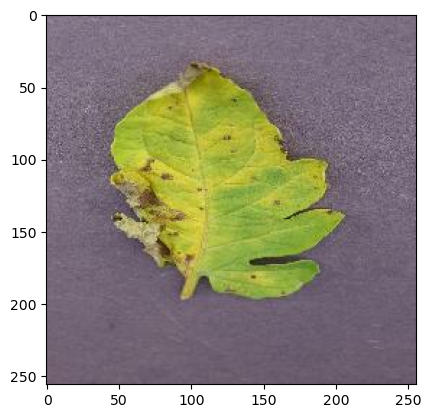

In [34]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_name[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_name[np.argmax(batch_prediction[0])])

In [35]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_name[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 64ms/step


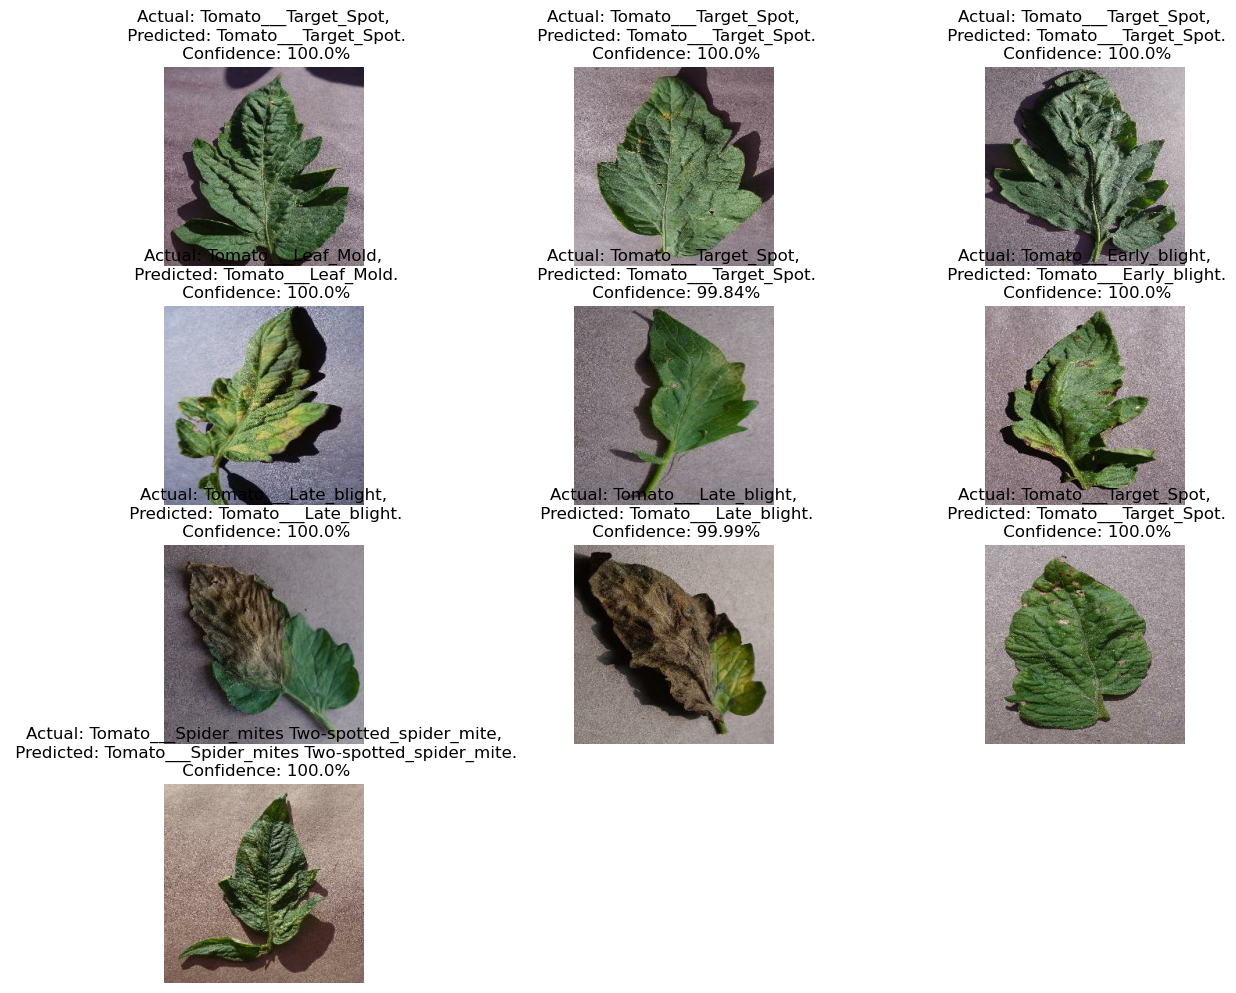

In [55]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(10):
        ax = plt.subplot(5, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_name[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [41]:
import os
model_version=max([int(i) for i in os.listdir("../model") + [0]])+1
model.save(f"../model/{model_version}")

INFO:tensorflow:Assets written to: ../model/5\assets


INFO:tensorflow:Assets written to: ../model/5\assets


NameError: name 'predict' is not defined

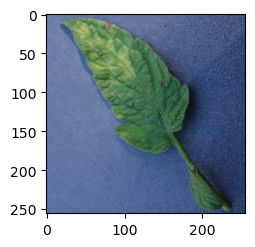

In [31]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(10):
        ax = plt.subplot(5, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(mp, images[i].numpy())
        actual_class = class_name[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [35]:
from tensorflow import keras

In [37]:
new_model = keras.models.load_model("../model/5")

In [ ]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(10):
        ax = plt.subplot(5, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(mp, images[i].numpy())
        actual_class = class_name[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")